# Model Evaluation 

### Load features 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load the processed flight and weather data
flights = pd.read_csv("../data/processed/flight_features.csv")
weather = pd.read_csv("../data/processed/weather_features.csv")

print("Flight Features Columns:", flights.columns.tolist())
print("Weather Features Columns:", weather.columns.tolist())

# Display the first few rows of flight data
flights.head()

Flight Features Columns: ['airline', 'origin', 'dest', 'distance', 'dep_hour', 'day_of_week', 'month', 'is_weekend', 'is_delayed']
Weather Features Columns: ['iata', 'date', 'hour', 'precipitation', 'cloud_cover', 'visibility']


,airline,origin,dest,distance,dep_hour,day_of_week,month,is_weekend,is_delayed
0,9E,JFK,DTW,509.0,12,1,1,0,0
1,9E,MSP,CLE,622.0,10,1,1,0,0
2,9E,JFK,RIC,288.0,14,1,1,0,0
3,9E,RIC,JFK,288.0,16,1,1,0,0
4,9E,DTW,MKE,237.0,10,1,1,0,0


### Merging 

In [ ]:

sample_size = 500000 
flights_sampled = flights.sample(n=sample_size, random_state=42)

# 3. Re-merge on the sample
# To avoid the "explosion," we will take the average weather per airport per hour
weather_avg = weather.groupby(['iata', 'hour']).agg({
    'precipitation': 'mean',
    'cloud_cover': 'mean',
    'visibility': 'mean'
}).reset_index()

df_final = pd.merge(
    flights_sampled, 
    weather_avg.rename(columns={'iata': 'origin', 'hour': 'dep_hour'}), 
    on=['origin', 'dep_hour'], 
    how='left'
)

# 4. Fill missing weather values with the global mean (Simple Imputation)
df_final['precipitation'] = df_final['precipitation'].fillna(df_final['precipitation'].mean())
df_final['cloud_cover'] = df_final['cloud_cover'].fillna(df_final['cloud_cover'].mean())
df_final['visibility'] = df_final['visibility'].fillna(df_final['visibility'].mean())

print(f"Fixed Shape: {df_final.shape}")
print(f"Missing values: {df_final.isnull().sum().sum()}")
df_final.head()

Fixed Shape: (500000, 12)
Missing values: 0


,airline,origin,dest,distance,dep_hour,day_of_week,month,is_weekend,is_delayed,precipitation,cloud_cover,visibility
0,AA,STT,MIA,1107.0,12,5,4,0,0,5.106080,66.715574,6.115990
1,UA,EWR,MIA,1085.0,8,1,5,0,0,4.982321,67.175300,6.167532
2,WN,HOU,SAT,192.0,21,2,7,0,1,4.984168,66.950412,6.180522
3,AS,SEA,IAH,1874.0,23,2,9,0,0,5.106080,66.715574,6.115990
4,AA,LGA,DFW,1389.0,12,5,5,0,0,5.037016,66.555709,6.169642


### Train/ Test Split

In [5]:
from sklearn.model_selection import train_test_split

# 1. Define the features (X) and the target (y)
# We use all columns except the target 'is_delayed'
X = df_final.drop('is_delayed', axis=1)
y = df_final['is_delayed']

# 2. Split the data: 80% for training, 20% for testing
# We use 'stratify=y' to ensure both sets have the same 80/20 delay ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
print(f"Delay distribution in training set: \n{y_train.value_counts(normalize=True)}")

Training set size: 400000 rows
Testing set size: 100000 rows
Delay distribution in training set: 
is_delayed
0    0.79874
1    0.20126
Name: proportion, dtype: float64


### Modeling 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Define feature types
cat_features = ['airline', 'origin', 'dest', 'day_of_week', 'month', 'is_weekend']
num_features = ['distance', 'dep_hour', 'precipitation', 'cloud_cover', 'visibility']

# 2. Define the Preprocessor (Handling leftover encoding/scaling)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# 3. Create a dictionary of models to train
# Note: we use class_weight='balanced' because of the 80/20 class imbalance
models = {
    "Logistic_Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random_Forest": RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', n_jobs=-1),
    "XGBoost": XGBClassifier(scale_pos_weight=4) # 4 is roughly the ratio of 80/20
}

# 4. Train and store results
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    clf.fit(X_train, y_train)
    
    # Store the trained pipeline
    results[name] = clf
    print(f"{name} trained successfully.")

Training Logistic_Regression...
Logistic_Regression trained successfully.
Training Random_Forest...
Random_Forest trained successfully.
Training XGBoost...
XGBoost trained successfully.


### Evaluation 


--- Model Performance Comparison ---
                 Model  Accuracy  Recall_Delayed  Precision_Delayed  \
2              XGBoost    63.891          0.6360             0.3078   
1        Random_Forest    62.282          0.6162             0.2925   
0  Logistic_Regression    61.943          0.6187             0.2907   

   F1_Score_Delayed  ROC_AUC  
2            0.4149   0.6907  
1            0.3967   0.6685  
0            0.3955   0.6647  

Visualizing Confusion Matrix for the best model: XGBoost


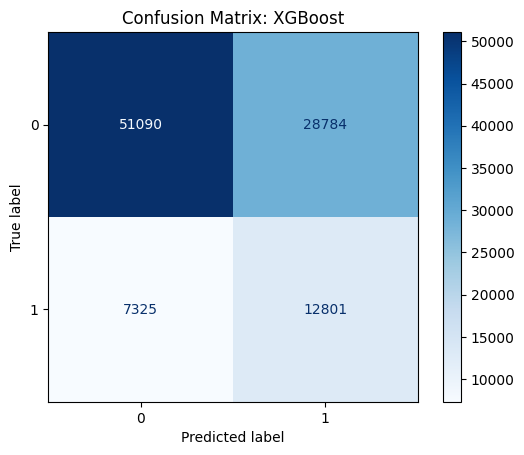

In [9]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Create a comparison table for metrics
performance_summary = []

for name, clf in results.items():
    # Get predictions
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    
    # Generate report
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred) # Adding Accuracy
    
    performance_summary.append({
        'Model': name,
        'Accuracy': acc * 100,
        'Recall_Delayed': report['1']['recall'],
        'Precision_Delayed': report['1']['precision'],
        'F1_Score_Delayed': report['1']['f1-score'],
        'ROC_AUC': auc
    })

# Convert to DataFrame for a clean table
perf_df = pd.DataFrame(performance_summary)

# Sort by F1-Score or ROC_AUC to see the winner at the top
perf_df = perf_df.sort_values(by='ROC_AUC', ascending=False)

print("\n--- Model Performance Comparison ---")
print(perf_df.round(4)) # Rounding to 4 decimals for readability

# Visualize the Confusion Matrix for the best model
from sklearn.metrics import ConfusionMatrixDisplay
best_model_name = perf_df.iloc[0]['Model']
print(f"\nVisualizing Confusion Matrix for the best model: {best_model_name}")

ConfusionMatrixDisplay.from_estimator(results[best_model_name], X_test, y_test, cmap='Blues')
plt.title(f"Confusion Matrix: {best_model_name}")
plt.grid(False) # Clean up the visual
plt.show()

In [10]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define the parameter grid
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 6, 10],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
    'classifier__scale_pos_weight': [3, 4, 5] # Tuning the imbalance handling
}

# 2. Re-create the XGBoost pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# 3. Run Randomized Search
# n_iter=5 means it will try 5 random combinations from the grid above
tuned_xgb = RandomizedSearchCV(
    xgb_pipeline, 
    param_distributions=param_grid, 
    n_iter=5, 
    scoring='roc_auc', 
    cv=3, 
    verbose=1, 
    random_state=42
)

print("Starting Hyperparameter Tuning...")
tuned_xgb.fit(X_train, y_train)

print(f"Best Parameters: {tuned_xgb.best_params_}")
print(f"Best ROC-AUC: {tuned_xgb.best_score_:.4f}")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


c:\Users\mtawa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:53:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\mtawa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:53:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\mtawa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:54:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\mtawa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:54:02] WARNING: C:\actio

Best Parameters: {'classifier__subsample': 0.8, 'classifier__scale_pos_weight': 4, 'classifier__n_estimators': 100, 'classifier__max_depth': 10, 'classifier__learning_rate': 0.1}
Best ROC-AUC: 0.6913


C:\Users\mtawa\AppData\Local\Temp\ipykernel_31668\857686974.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


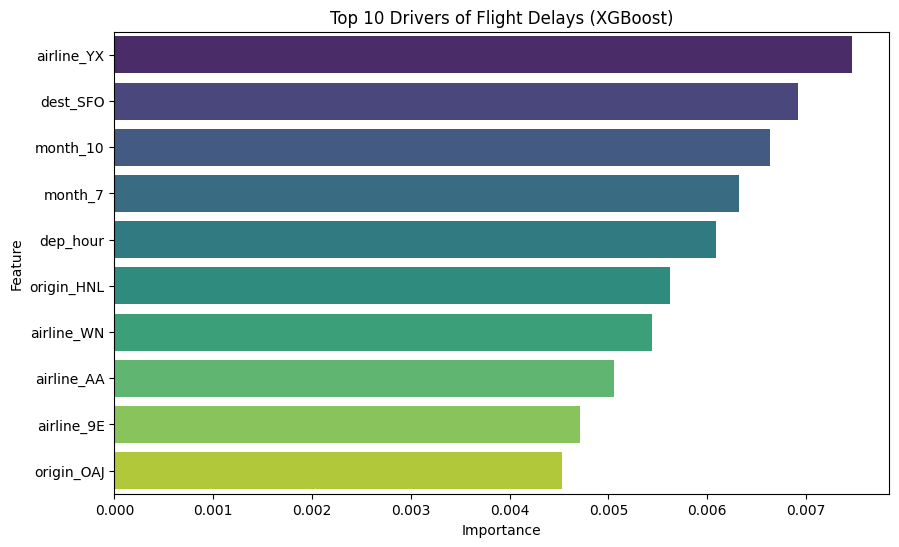

In [11]:
# 1. Get the best estimator from the tuning
final_model = tuned_xgb.best_estimator_

# 2. Extract feature importance from the classifier
importance = final_model.named_steps['classifier'].feature_importances_

# 3. Get the feature names after one-hot encoding
# This part is tricky because the OneHotEncoder creates many new columns
ohe_feature_names = final_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features)
all_feature_names = np.concatenate([num_features, ohe_feature_names])

# 4. Create a DataFrame for visualization
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importance})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10) # Top 10

# 5. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 10 Drivers of Flight Delays (XGBoost)')
plt.show()